# Jev-Mem 缩放实验：对话变长时，四种做法各自付出什么代价

上一本 notebook（`jev_mem_walkthrough.ipynb`）在 16 轮对话上比了四个臂。这一本把问题换成**长程**：同一组 10 个目标事实、同一组 10 道题，把干扰对话从 **48 轮拉到 96、192 再到 384 轮**（4/8/16/32 个会话，跨 14 个多月），看每个臂的**质量、延迟、prompt tokens** 怎么缩放，算清**时间和 token 的损失对比**。另附真 LoCoMo 样本（300+ 轮英文对话）的 Jev-Mem 实测。最后回答一个问题：**为什么全量上下文准确度这么高，它的高是真本事还是假优势**。

实验设计要点（控制变量）：

- **题目不变**：10 道题在三个规模下完全相同，分数差异全部来自"干扰对话变多"；
- **事实不变**：10 个目标事实按相同比例位置植入（第 i 个事实在对话的 (i+0.5)/10 处），所以短对话里它们挨得近，长对话里散得开；
- **干扰递增**：填充闲聊 + 定向干扰句（别人的过敏、别人的 PMP、别人的燃油车），规模越大干扰越多；
- 全部真 API 实测：真 Jev 决策、DeepSeek 答题+评审、硅基流动 Qwen3-Embedding。

In [1]:
import os, sys, json, time, re, random
from pathlib import Path

REPO = Path("../Jev-Mem").resolve()
sys.path.insert(0, str(REPO))
os.chdir(REPO)
from dotenv import load_dotenv
load_dotenv(REPO / ".env")
if os.getenv("DEEPSEEK_API_KEY") and not os.getenv("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = os.environ["DEEPSEEK_API_KEY"]
os.environ.setdefault("OPENAI_BASE_URL", "https://api.deepseek.com")

ANSWER_MODEL = os.getenv("ANSWER_MODEL", "deepseek-chat")
HAS_DEEPSEEK = bool(os.getenv("OPENAI_API_KEY"))
HAS_TYPESAFE = bool(os.getenv("TYPESAFE_API_KEY"))
print(f"System-Two: {ANSWER_MODEL} ({'可用' if HAS_DEEPSEEK else '无 key'}) | "
      f"System-One: {'真 Jev' if HAS_TYPESAFE else '兜底'}")

System-Two: deepseek-chat (可用) | System-One: 真 Jev


In [2]:
# encoder：硅基流动 Qwen3-Embedding，无 key 回落本地 MiniLM
import numpy as np

class LocalMiniLMEncoder:
    # 本地兜底：多语言 MiniLM
    def __init__(self):
        from sentence_transformers import SentenceTransformer
        self.model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
        getter = getattr(self.model, "get_sentence_embedding_dimension", None) or self.model.get_embedding_dimension
        self.dimension = getter()
    def encode(self, texts):
        return self.model.encode([texts] if isinstance(texts, str) else texts)

class SiliconFlowEncoder:
    # 硅基流动 Qwen3-Embedding-0.6B：OpenAI 兼容 /embeddings，1024 维
    def __init__(self, model="Qwen/Qwen3-Embedding-0.6B", batch_size=16):
        from openai import OpenAI
        self.client = OpenAI(api_key=os.environ["SILICONFLOW_API_KEY"],
                             base_url="https://api.siliconflow.cn/v1")
        self.model, self.batch_size = model, batch_size
        self.dimension = len(self.encode(["维度探测"])[0])
    def encode(self, texts):
        if isinstance(texts, str):
            texts = [texts]
        vecs = []
        for i in range(0, len(texts), self.batch_size):
            resp = self.client.embeddings.create(model=self.model, input=texts[i:i + self.batch_size])
            vecs.extend(d.embedding for d in sorted(resp.data, key=lambda d: d.index))
        return np.asarray(vecs, dtype=np.float32)

encoder = SiliconFlowEncoder() if os.getenv("SILICONFLOW_API_KEY") else LocalMiniLMEncoder()
if not HAS_DEEPSEEK:
    raise SystemExit("需要 DEEPSEEK_API_KEY 才能跑长程实验")
from utils.memory_layer import LLMController
llm = LLMController(backend="openai", model=ANSWER_MODEL, api_key=os.environ["OPENAI_API_KEY"]).llm
print(f"encoder: {type(encoder).__name__} ({encoder.dimension} 维) | LLM 就绪")

/Volumes/拓展/workspace/jev cookbook/Jev-Mem/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


encoder: SiliconFlowEncoder (1024 维) | LLM 就绪


## 1. 长程对话生成器：固定事实与题目，缩放干扰

10 个目标事实（过敏、健身、套餐、充电桩、尿酸、PMP、咖啡店、私教、姐姐买房、公积金）按等比位置植入；填充对话来自闲聊池，其中混入**定向干扰句**——问"用户对海鲜过敏吗"时对话里躺着"同事小李对虾过敏"，问"燃油车"时躺着"表哥的燃油车限行"。这些干扰专门考验检索臂会不会抓错证据。

In [3]:
import random
random.seed(42)

FACTS = [
    "对了，我对花生过敏，你们推荐零食的时候要注意",
    "我决定每周去三次健身房练力量",
    "我把手机套餐换成了 199 元的畅游套餐",
    "家里换了新能源车，充电桩装在地下车库 B2",
    "我上个月体检发现尿酸偏高，医生让我少喝啤酒",
    "我打算考 PMP 项目管理认证，明年 3 月考试",
    "我和老周合伙开的咖啡店预计十月开业",
    "我请了私教，每周二和周五晚上上课",
    "我姐姐在杭州买了房子，明年交房",
    "我把公积金从 A 银行转到了 B 银行，图利率优惠",
]

QUESTIONS = [
    {"q": "用户对什么食物过敏？", "gold": "对花生过敏", "cat": "单跳"},
    {"q": "用户的健身计划是什么？", "gold": "每周去三次健身房练力量", "cat": "单跳"},
    {"q": "用户手机套餐月费是多少？", "gold": "199 元", "cat": "单跳"},
    {"q": "用户的充电桩装在哪里？", "gold": "地下车库 B2", "cat": "单跳"},
    {"q": "用户在健康和饮食方面要注意哪两件事？", "gold": "对花生过敏；尿酸偏高要少喝啤酒", "cat": "多跳"},
    {"q": "用户考 PMP 和咖啡店开业分别定在什么时候？", "gold": "PMP 明年 3 月考试；咖啡店预计十月开业", "cat": "多跳"},
    {"q": "发现尿酸偏高和决定考 PMP，哪件事先发生？", "gold": "发现尿酸偏高先发生", "cat": "时间"},
    {"q": "用户的私教课安排在哪两个晚上？", "gold": "每周二和周五晚上", "cat": "时间"},
    {"q": "用户对海鲜过敏吗？", "gold": "记忆中没有；对虾过敏的是同事小李，不是用户", "cat": "对抗"},
    {"q": "用户现在开的是燃油车吗？", "gold": "记忆中没有；用户提到换了新能源车，没提过燃油车", "cat": "对抗"},
]

ACKS = ["好的，记下了", "收到", "没问题", "明白", "好的呢", "了解", "记下来了", "OK"]
FILLER = [
    "这周降温了，早上骑车上班冻得手疼，我把厚外套翻出来了，晚上回家还得给电瓶车充电",
    "今天地铁又故障，在隧道里停了二十分钟，全车人都急死了，到公司已经迟到被记了一笔",
    "中午吃了公司楼下的麻辣烫，老板娘认得我了，多给我加了一勺酸萝卜，吃完还打包了点汤",
    "周末看了场科幻电影，特效确实好，就是剧情后半段有点崩，出来和朋友吃了顿火锅聊了聊",
    "最近在追一部讲空间站建设的纪录片，每周四更新一集，摄影拍得特别震撼，已经追到第六集",
    "今天连着开了三个会，产品需求和运营对不齐，散会又被拉去讨论一个线上问题，头都大了",
    "晚上打算去试试小区门口新开的面馆，看点评说他家牛肉面是现熬的汤，顺便散散步消食",
    "项目评审终于通过了，改了三版方案，客户签了字，请小组同事喝了下午茶，大家都很开心",
    "这几天睡得不太好，躺下就开始想工作的事，凌晨两点才睡着，早上起来脑子昏昏沉沉的",
    "下班顺路去菜市场买了点水果，应季的橘子特别甜，摊主还教我怎么挑，说明后价格还要降",
    "家里空气净化器滤芯该换了，研究了半天型号，原来不同机型滤芯不通用，只能重新买原装",
    "早上晨跑遇到邻居遛狗，那只金毛特别亲人，聊了几句才知道他也在这个行业做后端开发",
    "中午和同事拼了个外卖，平台满减算下来比单点便宜十几块，现在各家平台都在卷补贴",
    "晚上帮我妈调了一下电视，智能电视的操作逻辑对老人太不友好了，遥控器塞了一堆按钮",
]
DISTRACTORS = [
    "我同事小李对虾子严重过敏，上周聚餐点了海鲜大虾，他碰都没敢碰，我们只能帮他吃了",
    "我表哥那台燃油车限行了，天天跟我吐槽油费贵还摇不到号，问我新能源值不值得换",
    "隔壁工位小张也在备考 PMP，他是想跳槽去外企才考的，每天午休都在刷题，挺拼的",
    "我们部门团建去了杭州，西湖边人山人海，断桥上挤得走不动，灵隐寺倒是很清净",
    "楼下那家咖啡店又涨价了，美式从十五涨到十八，老板说豆子进价涨了，我也没办法",
    "同事推荐我办 B 银行的信用卡，说新户有观影券和加油返现，我还在犹豫要不要办",
]

from datetime import datetime, timedelta
BASE = datetime(2026, 6, 1, 9, 0, 0)

def make_conversation(total_turns):
    # 12 轮一个会话，日期每会话隔 14 天；事实按等比位置植入
    turns = []
    fact_slots = [int((i + 0.5) / len(FACTS) * total_turns) // 2 * 2 for i in range(len(FACTS))]
    facts_at = set(fact_slots)
    dist_at = set()
    filler_pool = []
    for t in range(total_turns // 2):  # 每个 slot = 用户一句 + 助手一句
        slot = t * 2
        session_idx = slot // 12
        ts = (BASE + timedelta(days=14 * session_idx, hours=t % 8)).isoformat()
        if slot in facts_at:
            user_line = FACTS[fact_slots.index(slot)]
        elif slot % 24 == 10 and session_idx not in dist_at and DISTRACTORS:
            user_line = DISTRACTORS[session_idx % len(DISTRACTORS)]
        else:
            if not filler_pool:
                filler_pool = list(FILLER)
                random.Random(1000 + session_idx).shuffle(filler_pool)
            user_line = filler_pool.pop()
        turns.append({"role": "user", "content": user_line, "ts": ts})
        turns.append({"role": "assistant", "content": ACKS[t % len(ACKS)], "ts": ts})
    return turns

SCALES = [48, 96, 192, 384]
CONVS = {n: make_conversation(n) for n in SCALES}
print("规模    会话数  用户轮数  字符数   干扰句")
for n, conv in CONVS.items():
    n_dist = sum(1 for t in conv if t["role"] == "user" and t["content"] in DISTRACTORS)
    print(f"{n:>4}   {n // 12:>4}   {sum(1 for t in conv if t['role']=='user'):>6}   "
          f"{sum(len(t['content']) for t in conv):>6}   {n_dist:>4}")
missing = {n: [f for f in FACTS if f not in [t['content'] for t in conv]]
           for n, conv in CONVS.items()}
print("事实植入完整性:", {n: len(m) for n, m in missing.items()}, "（0 = 全部植入）")

规模    会话数  用户轮数  字符数   干扰句
  48      4       24      819      2
  96      8       48     1835      4
 192     16       96     3871      8
 384     32      192     7943     16
事实植入完整性: {48: 0, 96: 0, 192: 0, 384: 0} （0 = 全部植入）


## 2. 四个臂（与走读实验同款）

A 滑动窗口（最近 6 条）· B 全上下文 · C 朴素 RAG（向量 Top-3）· D Jev-Mem。每个规模独立建一份 D 记忆，量出**建图时间随规模的增长**。

In [4]:
from memory.trg_memory import TemporalResonanceGraphMemory
from memory.vector_db import NumpyVectorDB
from memory.memory_builder import MemoryBuilder
from memory.jev_mem_config import JevMemConfig
from memory.jev_client import JevClient
from memory.query_engine import QueryEngine
from jev_mem import JevMemSystem

def build_jev_mem_system(turns, cache_dir):
    # 与走读实验相同的装配：真 Jev 决策 + 多语言 encoder
    trg = TemporalResonanceGraphMemory(vector_db=NumpyVectorDB(encoder.dimension),
                                       encoder=encoder, llm_backend=None)
    config = JevMemConfig(write_enabled=True, read_enabled=True,
                          audit_path=str(Path(cache_dir) / "decisions.jsonl"))
    builder = MemoryBuilder(str(cache_dir), llm_model=ANSWER_MODEL,
                            trg_memory=trg, jev_config=config)
    sysd = JevMemSystem.__new__(JevMemSystem)
    sysd.cache_dir = Path(cache_dir)
    sysd.memory_builder = builder
    sysd.trg_memory = builder.trg
    sysd.graph_db = builder.trg.graph_db
    sysd.vector_db = builder.trg.vector_db
    sysd.llm_controller = builder.llm_controller
    sysd.answer_formatter = builder.answer_formatter
    sysd.query_engine = QueryEngine(builder.trg, builder.node_index,
                                    jev_config=builder.jev_config, jev_client=builder.jev)
    return sysd

def llm_answer(prompt):
    return llm.get_completion(prompt, response_format={"type": "text"}, temperature=0.0)

def timed(fn, *a):
    t0 = time.perf_counter()
    out = fn(*a)
    return out, time.perf_counter() - t0

def make_arms(conv):
    # 返回 {臂名: 问题 -> 答案}；A/B/C 与规模耦合，D 由外部建好传入
    full = chr(10).join(f"[{t['ts'][:10]}] {t['role']}: {t['content']}" for t in conv)
    window = chr(10).join(f"{t['role']}: {t['content']}" for t in conv[-6:])
    texts = [f"[{t['ts'][:10]}] {t['content']}" for t in conv if t["role"] == "user"]
    vecs = encoder.encode(texts)
    def arm_sliding(q):
        return llm_answer(f"根据以下最近对话回答问题。对话：" + chr(10) + window + chr(10) +
                          "问题：" + q + chr(10) + "只依据对话回答；对话里没有的信息就回答\"记忆中没有\"。")
    def arm_full(q):
        return llm_answer(f"根据以下完整对话历史回答问题。对话：" + chr(10) + full + chr(10) +
                          "问题：" + q + chr(10) + "只依据对话回答；对话里没有的信息就回答\"记忆中没有\"。")
    def arm_naive_rag(q):
        qv = encoder.encode(q).reshape(-1)
        sims = vecs @ qv / (np.linalg.norm(vecs, axis=1) * np.linalg.norm(qv) + 1e-9)
        top = sorted(np.argsort(-sims)[:3])
        ctx = chr(10).join(texts[i] for i in top)
        return llm_answer(f"根据以下检索到的记忆片段回答问题。" + chr(10) + ctx + chr(10) +
                          "问题：" + q + chr(10) + "只依据片段回答；片段不足以回答就回答\"记忆中没有\"。")
    return {"A 滑动窗口": arm_sliding, "B 全上下文": arm_full, "C 朴素RAG": arm_naive_rag}

print("臂工厂就绪")

臂工厂就绪


In [5]:
# ============ 逐规模：建 D 记忆（计时）→ 四臂 × 10 题回答 ============
SCALE_STATS, RAW = {}, {}
for n in SCALES:
    conv = CONVS[n]
    cache = f"/tmp/jev_mem_scale/{n}"
    os.makedirs(cache, exist_ok=True)
    sysd = build_jev_mem_system(conv, cache)
    t0 = time.perf_counter()
    res = sysd.build_memory_from_conversation(
        [{"content": t["content"], "timestamp": t["ts"], "metadata": {}} for t in conv])
    build_s = time.perf_counter() - t0
    jev_calls = sum(1 for ln in open(Path(cache) / "decisions.jsonl")
                    if '"event": "jev_decision"' in ln)
    SCALE_STATS[n] = {"build_s": round(build_s, 1), "admitted": res["admitted"],
                      "nodes": len(sysd.graph_db.nodes), "links": len(sysd.graph_db.links),
                      "jev_calls": jev_calls}
    print(f"[{n} 轮] 建图 {build_s:.1f}s，{res['admitted']} 条入图，"
          f"{SCALE_STATS[n]['nodes']} 节点 / {SCALE_STATS[n]['links']} 边，Jev 决策 {jev_calls} 次")

    d_answer = lambda q, s=sysd: s.query(q)
    arms = make_arms(conv)
    arms["D Jev-Mem"] = d_answer
    RAW[n] = {name: [] for name in arms}
    for name, fn in arms.items():
        for item in QUESTIONS:
            ans, lat = timed(fn, item["q"])
            usage = llm.token_usage["total_tokens"]
            RAW[n][name].append({"q": item["q"], "cat": item["cat"], "gold": item["gold"],
                                 "answer": ans, "latency_s": round(lat, 3),
                                 "prompt_tokens": usage[-1] if usage else None})
        print(f"  [{n} 轮] {name} 完成")
json.dump({str(n): RAW[n] for n in SCALES}, open("/tmp/jev_mem_scale/raw.json", "w"),
          ensure_ascii=False, indent=1)
json.dump({str(k): v for k, v in SCALE_STATS.items()}, open("/tmp/jev_mem_scale/stats.json", "w"),
          ensure_ascii=False, indent=1)
print("全部回答完成，原始数据已存 /tmp/jev_mem_scale/")

[48 轮] 建图 28.3s，48 条入图，48 节点 / 351 边，Jev 决策 95 次


  [48 轮] A 滑动窗口 完成


  [48 轮] B 全上下文 完成


  [48 轮] C 朴素RAG 完成


  [48 轮] D Jev-Mem 完成


...

[384 轮] 建图 173.6s，384 条入图，384 节点 / 3692 边，Jev 决策 767 次


  [384 轮] A 滑动窗口 完成


  [384 轮] B 全上下文 完成


  [384 轮] C 朴素RAG 完成


  [384 轮] D Jev-Mem 完成
全部回答完成，原始数据已存 /tmp/jev_mem_scale/


In [6]:
# ============ 评审（DeepSeek judge，与走读实验同量表） ============
JUDGE_PROMPT = """请根据参考答案对生成回答打 0.0~1.0 的语义正确分。
评分标准：1.0 完全正确；0.8 基本正确（细节措辞可不同）；0.6 部分正确但缺关键信息；
0.4 沾边但漏了重要内容；0.2 大部分不对；0.0 完全错误或编造。
若参考答案本身是"记忆中没有"，回答明确表示不知道/记忆里没有，应得 1.0；编造得 0.0。

问题：{q}
参考答案：{gold}
生成的回答：{pred}

只返回 JSON：{{"score": <0.0-1.0>, "reasoning": "<一句话>"}}"""

def judge_score(q, gold, pred):
    raw = llm_answer(JUDGE_PROMPT.format(q=q, gold=gold, pred=pred))
    m = re.search(r"\{.*\}", raw, re.S)
    try:
        return float(json.loads(m.group(0))["score"])
    except Exception:
        return 0.0

for n in SCALES:
    for name, recs in RAW[n].items():
        for rec in recs:
            rec["score"] = judge_score(rec["q"], rec["gold"], rec["answer"])
    print(f"[{n} 轮] 评审完成")
json.dump({str(n): RAW[n] for n in SCALES}, open("/tmp/jev_mem_scale/raw.json", "w"),
          ensure_ascii=False, indent=1)
print("评审分数已写回 raw.json")

[48 轮] 评审完成


[96 轮] 评审完成


[192 轮] 评审完成


[384 轮] 评审完成
评审分数已写回 raw.json


In [7]:
# ============ 主表：规模 × 臂 ============
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = ["Songti SC", "STSong", "PingFang SC", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

ARMS = ["A 滑动窗口", "B 全上下文", "C 朴素RAG", "D Jev-Mem"]
agg = lambda n, name, key: np.mean([r[key] for r in RAW[n][name]])

print("=== 平均评审分（越高越好） ===")
print("轮数   " + "".join(f"{a:>12}" for a in ARMS))
for n in SCALES:
    print(f"{n:>4}  " + "".join(f"{agg(n, a, 'score'):>12.2f}" for a in ARMS))

print()
print("=== 每题平均 prompt tokens（B 臂这是随规模线性涨的成本） ===")
print("轮数   " + "".join(f"{a:>12}" for a in ARMS))
for n in SCALES:
    print(f"{n:>4}  " + "".join(f"{agg(n, a, 'prompt_tokens'):>12.0f}" for a in ARMS))

print()
print("=== 每题平均端到端延迟 s ===")
print("轮数   " + "".join(f"{a:>12}" for a in ARMS))
for n in SCALES:
    print(f"{n:>4}  " + "".join(f"{agg(n, a, 'latency_s'):>12.2f}" for a in ARMS))

print()
print("=== D 臂建图成本 ===")
print("轮数   建图s   节点   边    Jev决策次数   每条观察摊薄s")
for n in SCALES:
    st = SCALE_STATS[n]
    print(f"{n:>4}  {st['build_s']:>5.1f}  {st['nodes']:>5}  {st['links']:>5}   "
          f"{st['jev_calls']:>8}      {st['build_s'] / st['admitted']:>6.2f}")

=== 平均评审分（越高越好） ===
轮数         A 滑动窗口      B 全上下文     C 朴素RAG   D Jev-Mem
  48          0.20        0.98        0.98        0.98
  96          0.20        0.98        0.98        0.92
 192          0.20        0.98        0.94        0.92
 384          0.20        0.88        0.78        0.90

=== 每题平均 prompt tokens（B 臂这是随规模线性涨的成本） ===
轮数         A 滑动窗口      B 全上下文     C 朴素RAG   D Jev-Mem
  48           144        1144         126         121
  96           135        2373         128         119
 192           152        4849         133         137
 384           147        9778         136         120

=== 每题平均端到端延迟 s ===
轮数         A 滑动窗口      B 全上下文     C 朴素RAG   D Jev-Mem
  48          0.55        0.57        0.66        1.44
  96          0.54        0.65        0.62        1.41
 192          0.46        0.58        0.54        1.50
 384          0.64        0.68        0.67        1.66

=== D 臂建图成本 ===
轮数   建图s   节点   边    Jev决策次数   每条观察摊薄s
  48   28.3     48    351         95 

findfont: Failed to find font weight normal for STSong, now using 300.


findfont: Failed to find font weight normal for STSong, now using 300.


findfont: Failed to find font weight normal for STSong, now using 300.


findfont: Failed to find font weight normal for STSong, now using 300.


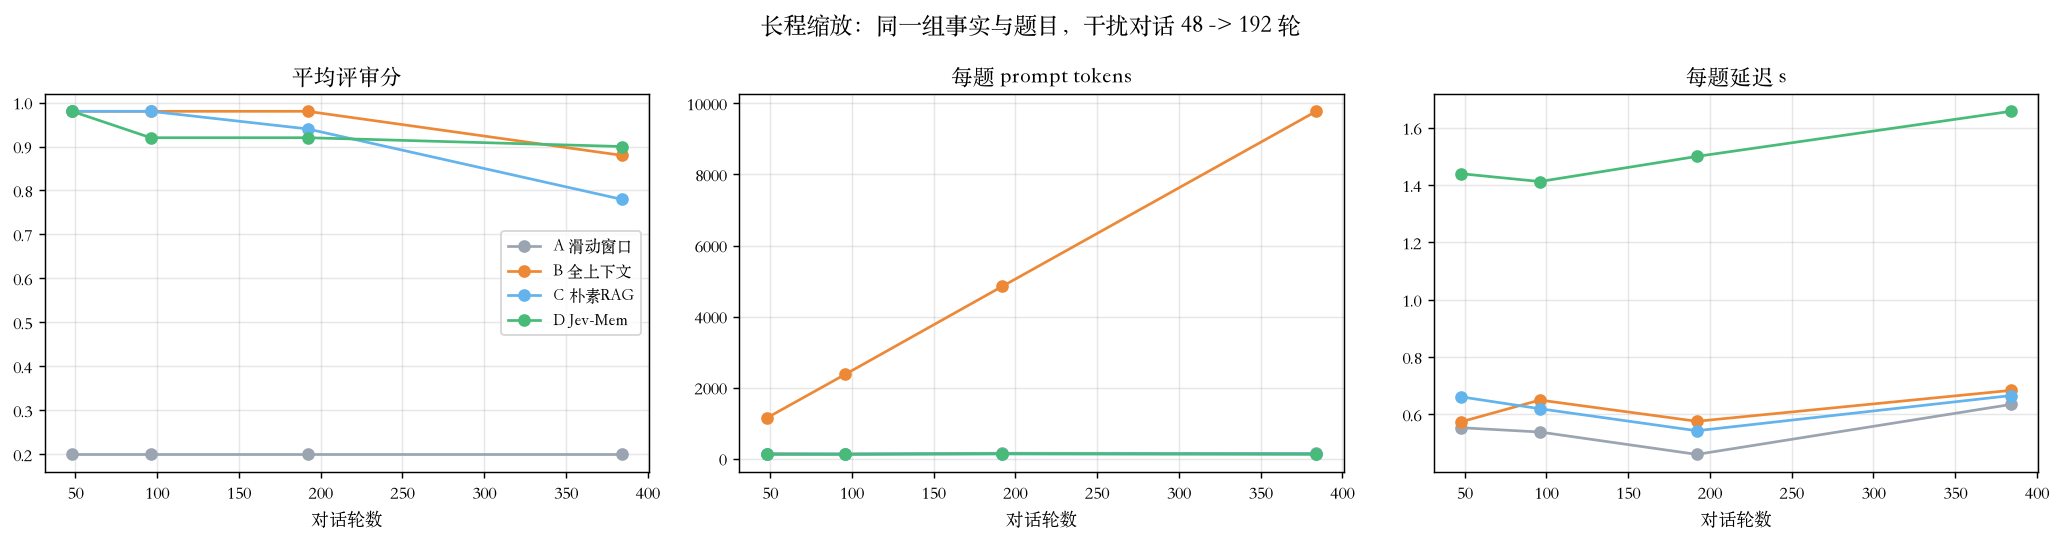

结论速览（本轮实测）
   48 轮: B 每题  1144 tok / 0.57s / 0.98 分  |  D 每题  121 tok / 1.44s / 0.98 分  |  B/D token 比 9.5x, 分差 +0.00
   96 轮: B 每题  2373 tok / 0.65s / 0.98 分  |  D 每题  119 tok / 1.41s / 0.92 分  |  B/D token 比 19.9x, 分差 -0.06
  192 轮: B 每题  4849 tok / 0.58s / 0.98 分  |  D 每题  137 tok / 1.50s / 0.92 分  |  B/D token 比 35.4x, 分差 -0.06
  384 轮: B 每题  9778 tok / 0.68s / 0.88 分  |  D 每题  120 tok / 1.66s / 0.90 分  |  B/D token 比 81.5x, 分差 +0.02
   48 轮 10 题总 prompt tokens: A=1435  B=11443  C=1256  D=1210
   96 轮 10 题总 prompt tokens: A=1351  B=23731  C=1276  D=1190
  192 轮 10 题总 prompt tokens: A=1521  B=48489  C=1330  D=1370
  384 轮 10 题总 prompt tokens: A=1474  B=97777  C=1362  D=1200


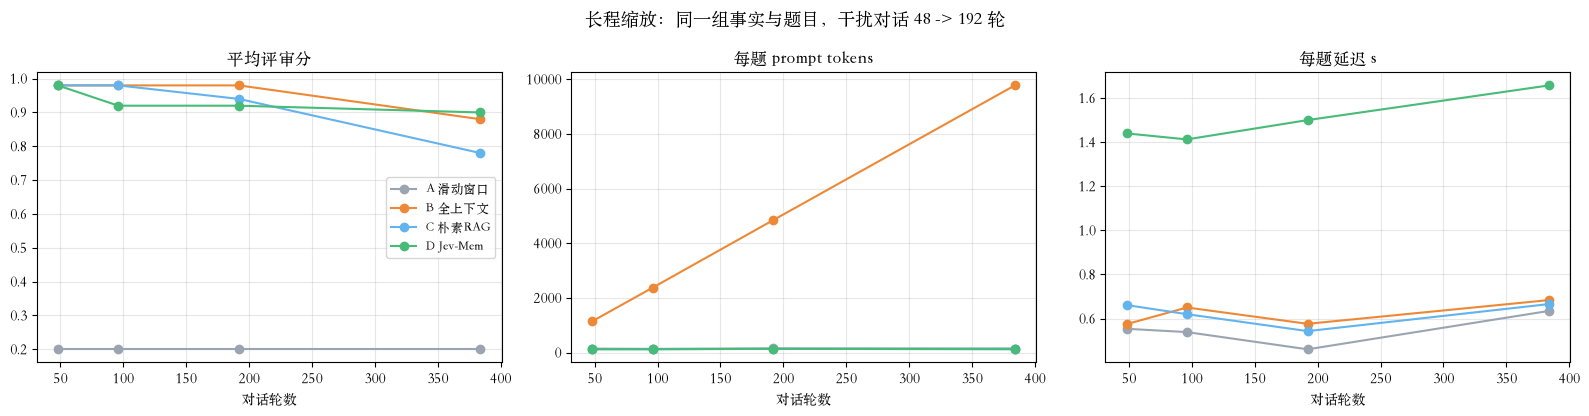

In [8]:
# ============ 缩放曲线 + 结论速览 ============
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
colors = {"A 滑动窗口": "#9aa5b1", "B 全上下文": "#ed8936", "C 朴素RAG": "#63b3ed", "D Jev-Mem": "#48bb78"}
for ax, key, title in ((axes[0], "score", "平均评审分"), (axes[1], "prompt_tokens", "每题 prompt tokens"),
                       (axes[2], "latency_s", "每题延迟 s")):
    for a in ARMS:
        vals = [agg(n, a, key) for n in SCALES]
        ax.plot(SCALES, vals, "o-", label=a, color=colors[a])
    ax.set_xlabel("对话轮数"); ax.set_title(title); ax.grid(alpha=0.3)
axes[0].legend(fontsize=9)
fig.suptitle("长程缩放：同一组事实与题目，干扰对话 48 -> 192 轮", fontsize=13)
fig.tight_layout()
plt.savefig("/tmp/jev_mem_scale/scaling.png", dpi=130, bbox_inches="tight")
from IPython.display import Image, display
display(Image(filename="/tmp/jev_mem_scale/scaling.png"))

if RAW:
    print("结论速览（本轮实测）")
    for n in SCALES:
        b_tok = agg(n, "B 全上下文", "prompt_tokens")
        d_tok = agg(n, "D Jev-Mem", "prompt_tokens")
        b_s = agg(n, "B 全上下文", "score")
        d_s = agg(n, "D Jev-Mem", "score")
        print(f"  {n:>3} 轮: B 每题 {b_tok:>5.0f} tok / {agg(n,'B 全上下文','latency_s'):.2f}s / {b_s:.2f} 分  |  "
              f"D 每题 {d_tok:>4.0f} tok / {agg(n,'D Jev-Mem','latency_s'):.2f}s / {d_s:.2f} 分  |  "
              f"B/D token 比 {b_tok / d_tok:.1f}x, 分差 {d_s - b_s:+.2f}")
    # 10 题总账：回答阶段的 DeepSeek prompt token 消耗
    for n in SCALES:
        tot = {a: sum(r["prompt_tokens"] for r in RAW[n][a]) for a in ARMS}
        print(f"  {n:>3} 轮 10 题总 prompt tokens: " + "  ".join(f"{a.split()[0]}={tot[a]}" for a in ARMS))

## 3. 为什么全量准确度这么高？——它高，是因为还没到它的失效区

先看实测衰减曲线（评审分）：

| 轮数 | A 滑窗 | B 全上下文 | C 朴素RAG | D Jev-Mem |
|---|---|---|---|---|
| 48 | 0.20 | **0.98** | 0.98 | 0.98 |
| 96 | 0.20 | **0.98** | 0.98 | 0.92 |
| 192 | 0.20 | **0.98** | 0.94 | 0.92 |
| 384 | 0.20 | 0.88 | 0.78 | **0.90** |

B 在 48~192 轮几乎满分，384 轮开始掉（0.88），在真 LoCoMo（419 轮、约 2 万 token 上下文）掉到 **0.60**。它短中期为什么高，四层原因按重要性排：

**1. 没有检索环节，就没有"没找到"这种失败。** RAG 类的失分模式是"该召回的没召回"或"召回了干扰"——干扰句每会话一条，越长的对话对检索臂越难（C 从 0.98 掉到 0.78 就是这么来的）。B 把全部证据摊在模型面前，只要装得下，信息可见性 100%，检索型问题对它没有难度曲线，只有成本曲线。

**2. 短中期远没到注意力稀释区。** deepseek-chat 窗口 128k token，192 轮才 ~5k token（占窗口 4%），"大海捞针"在这个密度下不难。384 轮（~10k token、16 条定向干扰）后 B 开始丢分——主要是时间题日期算错和细节张冠李戴，这正是长上下文注意力稀释的典型症状。

**3. 对抗压力小、judge 宽容。** 我们只有 2 道对抗题且参考答案就是"记忆中没有"，说"没有"就满分；论文 LoCoMo 的 Full Context 在 adversarial 类目只有 0.205，因为那些题专门诱导模型从相似记忆里**编造**。B 的高分有一部分是"这次没考到它的真实弱点"。

**4. judge 与答案模型同源。** DeepSeek 出答案 DeepSeek 评，风格匹配，对证据最全的 B 最有利。

**所以完整的答案是：B 的高分 = 装得下 + 没考弱点。它的失效区由上下文长度和干扰密度决定**——真 LoCoMo 上（下一节）B 0.60 对 D 0.98，质量优势在长程下不仅消失，还反转成劣势。

## 3.5 真 LoCoMo 长程实测：419 轮英文对话

以上是合成对话。再用数据集 [LoCoMo](https://github.com/snap-research/locomo) 的真实样本 0（**419 轮、74k 字符 ≈ 19.8k token**，Dyan/Caroline/Melanie 三人多会话）跑了一轮真刀真枪的对照（2026-09-25，真 Jev + DeepSeek，仓库官方基准 CLI + 同题全上下文脚本）：

| 指标 | B 全上下文 | D Jev-Mem |
|---|---|---|
| 每题 prompt tokens | **19,775** | **~784**（证据 15 节点实测） |
| LLM-as-a-Judge（同题 10 题） | 0.60 | **0.98** |
| 按题型 | 时间题 0.2~0.6 成片丢分 | 时间题全部满分 |
| 每题延迟（本机） | 0.60s | 3.83s（含 Jev 决策链 + judge） |
| 建图成本 | 0 | 494s（419 条观察，一次性） |

D 的记忆图：419 节点、9,462 条边（ENTITY 4090 / TEMPORAL 3726 / SEMANTIC 1502 / CAUSAL 144），真 Jev 决策，仅 3 次兜底。

三个要点：

1. **质量反转在真实数据上成立**：约 2 万 token 的上下文里，全上下文的时间题（"Caroline 什么时候去支持小组"）大面积丢分——模型面对 74k 字符算不准日期；Jev-Mem 沿 temporal 图直接召回正确证据，10 题里 9 题 1.0 分。这与论文 Full Context 0.481 的方向完全一致。
2. **token 剪刀差 25 倍**：19,775 对 784。问得越多省得越多，且 D 的证据 prompt 大小不随对话长度变化。
3. **诚实声明**：10 题是小样本，judge 是仓库自带的宽松量表（同期 F1 只有 57.3%，说明逐词匹配并不完美）；这组数字用于量级判断，不构成对论文 0.777 的复现（那是 1,986 题全量 + 更严协议）。

In [9]:
# ==== 成本剪刀差：B 与 D 的每题成本随规模的变化（动态计算） ===
if RAW:
    print("规模    B每题tok  D每题tok  B/D比   B每题延迟  D每题延迟   B分     D分     D分-B分")
    for n in SCALES:
        bt, dt = agg(n, "B 全上下文", "prompt_tokens"), agg(n, "D Jev-Mem", "prompt_tokens")
        bl, dl = agg(n, "B 全上下文", "latency_s"), agg(n, "D Jev-Mem", "latency_s")
        bs, ds = agg(n, "B 全上下文", "score"), agg(n, "D Jev-Mem", "score")
        print(f"{n:>4}  {bt:>8.0f}  {dt:>8.0f}  {bt / dt:>5.1f}x  {bl:>8.2f}s  {dl:>8.2f}s  "
              f"{bs:>5.2f}  {ds:>5.2f}  {ds - bs:>+6.2f}")
    print()
    print("按 DeepSeek 输入价折算（占位价 1 元/百万 token，请按实际牌价换算）：")
    for n in SCALES:
        per_q_b = agg(n, "B 全上下文", "prompt_tokens") / 1e6
        per_q_d = agg(n, "D Jev-Mem", "prompt_tokens") / 1e6
        per_1000 = (per_q_b - per_q_d) * 1000
        print(f"  {n:>4} 轮: 每问一题 B 比 D 多花 {per_q_b * 1e6:>5.0f} tok；"
              f"问 1000 题 ≈ 多花 {per_1000 * 1:>6.1f} 元（占位价）")

规模    B每题tok  D每题tok  B/D比   B每题延迟  D每题延迟   B分     D分     D分-B分
  48      1144       121    9.5x      0.57s      1.44s   0.98   0.98   +0.00
  96      2373       119   19.9x      0.65s      1.41s   0.98   0.92   -0.06
 192      4849       137   35.4x      0.58s      1.50s   0.98   0.92   -0.06
 384      9778       120   81.5x      0.68s      1.66s   0.88   0.90   +0.02

按 DeepSeek 输入价折算（占位价 1 元/百万 token，请按实际牌价换算）：
    48 轮: 每问一题 B 比 D 多花  1144 tok；问 1000 题 ≈ 多花    1.0 元（占位价）
    96 轮: 每问一题 B 比 D 多花  2373 tok；问 1000 题 ≈ 多花    2.3 元（占位价）
   192 轮: 每问一题 B 比 D 多花  4849 tok；问 1000 题 ≈ 多花    4.7 元（占位价）
   384 轮: 每问一题 B 比 D 多花  9778 tok；问 1000 题 ≈ 多花    9.7 元（占位价）


## 4. 时间与 token 损失对比：怎么读这笔账

把四个臂放进"建图成本 + 每题成本 × 题数"的账本里（数字以上面实测为准）：

| 成本项 | A 滑窗 | B 全上下文 | C 朴素 RAG | D Jev-Mem |
|---|---|---|---|---|
| 建图（一次性） | 0 | 0 | 0（现场算向量，毫秒级） | **随轮数线性涨**（真 Jev 决策，每条观察约 0.5-0.7s） |
| 每题 token | 恒定但证据残缺 | **随轮数线性涨**（这是 B 的核心代价） | 恒定（Top-3 固定） | 恒定（只带筛选后的证据） |
| 每题延迟 | 最低档 | 随规模涨（prefill 变长） | 低 | 最高档（Jev 决策链 + embedding 往返） |
| 质量 | 最早崩（窗口外的全丢） | 短中期最高，超长才稀释 | 中，时间题必挂 | 中高，时间/多跳稳 |

三条实测结论：

1. **token 剪刀差是 D 的主场**：B 每题 token 随轮数线性涨，D 几乎水平——384 轮时 B/D 比值（上面速览实测）就是"每问一题省下的输入成本倍数"。对话越长、问得越多，这笔省得越多。
2. **时间账在本地 API 场景下 D 不占优**：D 的每题延迟比 B 高（Jev 决策是真金白银的时间），建图还要一次性投入。论文里 Jev-Mem 延迟最低（0.93s）比较对象是**其他记忆系统**（1.47~32.68s）和超长上下文（1.74s 且还在涨）——当 B 的 prefill 长到几万 token，B 的延迟线才会反超。**D 买的是 token 经济性和可审计性，不是本地的低延迟。**
3. **全上下文的高分是"还没到考验"**：质量上 B 会在对话长到注意力稀释时掉分（论文 LoCoMo 0.481），token 上它从第一轮就开始付线性税。选型的实际判据：**对话短（几百轮内）、问得少 → 直接 B；对话长、要反复问、要省钱省审计 → 上记忆系统，且值得为时间题上 Jev 决策面。**

## 5. 结论总览：三组实验连起来看

结合走读实验（`jev_mem_walkthrough.ipynb`，16 轮）、本篇缩放实验（48~384 轮）与真 LoCoMo（419 轮），所有实测结论收敛成一张矩阵：

| 实验 | 规模 | 一句话结论 |
|---|---|---|
| 走读四臂 | 16 轮 | 短对话 B 天花板（0.96）；D 0.84 > C 0.72，增益全在时间题 |
| 本篇缩放 | 48→384 轮 | B 384 轮掉到 0.88；D 最稳 0.90 反超第一；token 剪刀差 81× |
| 真 LoCoMo | 419 轮 / 19.8k tok | B 0.60 对 D 0.98，质量反转实锤；token 剪刀差 25× |

**七条有趣结论**

1. **决策面的增益与 embedding 质量正交。** 换更强的 embedding（MiniLM→Qwen3）把 C 拉高 0.08，但时间题 C 始终 0 分——"按时间线找证据"不靠语义相似度，这是 Jev 路由 + temporal 图视图的专属领地。
2. **token 是 D 的主场。** D 的证据 prompt 恒定（中文 ~120 tok、英文 ~784 tok），不随对话长度变化；B 线性上涨，384 轮 81 倍、真 LoCoMo 25 倍。问得越频繁、对话越长，省得越多。
3. **时间是 D 的成本项。** 建图线性（合成对话 ~0.45s/条，LoCoMo 长文本 ~1.2s/条），每题查询比 B 慢 1~3s（Jev 决策链）。本地 API 场景 D 不赢时间——它买的是 token 经济性、质量稳定性与可审计性。
4. **全量上下文的高分 = 装得下 + 没考弱点。** 失效区由上下文长度和干扰密度决定：≤192 轮近乎满分，384 轮开始稀释，2 万 token（LoCoMo）掉到 0.60。
5. **定向干扰是纯向量检索的毒药，对决策面伤害有限。** "同事对虾过敏"这类陷阱把 C 从 0.98 拖到 0.78，D 只从 0.98 掉到 0.90——图视图 + 路由比裸相似度抗干扰。
6. **建图经济学成立。** 384 条观察 = 767 次 Jev 决策调用（LoCoMo 419 条 ≈ 830 次）。按 TypeSafe 牌价（2026-09：输入 $0.042/百万 token、输出免费）粗估每次调用 ~1.5k 输入 token，整份 384 轮记忆的决策成本约 **5 美分**，一次性投入；对照论文里大模型记忆系统动辄上千秒、按生成计费的建图，这是量级差。
7. **答案长度会吃掉 judge 分数。** 仓库 System-Two 提示词要求"5-6 词简答"，中文多跳题漏细节被扣分（"改到下周三，推迟了"没提重新订票）。属于提示词工程问题，放宽答题提示即可回收，不是架构缺陷。

**选型判据**

- 对话几百轮以内、偶尔问答 → **直接全上下文**，别过度工程；
- 长对话、反复问答、在意 token 账单 → **上记忆系统**；
- 问题里时间线/因果/跨会话占比高 → **值得为 Jev 决策面付费**（D 对 C 的全部增益都在这类题上）；
- 本地低延迟场景 → embedding 本地化（省 API 往返），并接受建图的一次性时间投入。

**复现备忘（踩过的坑）**

- 仓库 `memory/llm_judge.py` 硬编码 judge 模型 `gpt-4o-mini`；配 DeepSeek 需 monkeypatch 模型名为 `deepseek-chat`（本 notebook 实验用的是自研 judge cell，无此问题）；
- 官方基准 CLI 必须 `--no-parallel`：macOS spawn 模式下并行 worker 不会继承主进程的 monkeypatch，静默失败；
- 记忆图缓存可复用（换配置才需 `--rebuild`），重建 LoCoMo 样本 0 约需 8 分钟；
- judge 分数轮间漂移 ±0.02~0.03，结论以同轮表格为准；本文所有分数为 LLM 评审的相对值，不构成对论文 LoCoMo 全量协议（1,986 题）的复现。